In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"

df = pd.read_csv(url)

In [4]:
print("Primeras 5 filas del DataFrame:")
print(df.head())

print("\nInformación general del DataFrame:")
df.info()

print("\nEstadísticas descriptivas para columnas numéricas:")
print(df.describe())

Primeras 5 filas del DataFrame:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   

In [5]:
print("Número de valores nulos por columna:")
print(df.isnull().sum())

Número de valores nulos por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


In [6]:
df_cleaned = df.dropna()
print(f"Dimensiones del DataFrame después de eliminar valores nulos: {df_cleaned.shape}")
print("\nValores nulos después de la limpieza:")
print(df_cleaned.isnull().sum())

Dimensiones del DataFrame después de eliminar valores nulos: (333, 8)

Valores nulos después de la limpieza:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64


### 3. Preparación de variables categóricas

Ahora, identificaremos las columnas categóricas (`species`, `island`, `sex`) y las prepararemos para la codificación. Mostraremos los valores únicos de cada una para entender su distribución.

In [7]:
print("Valores únicos en la columna 'species':")
print(df_cleaned['species'].unique())

print("\nValores únicos en la columna 'island':")
print(df_cleaned['island'].unique())

print("\nValores únicos en la columna 'sex':")
print(df_cleaned['sex'].unique())

Valores únicos en la columna 'species':
['Adelie' 'Gentoo' 'Chinstrap']

Valores únicos en la columna 'island':
['Torgersen' 'Biscoe' 'Dream']

Valores únicos en la columna 'sex':
['male' 'female']


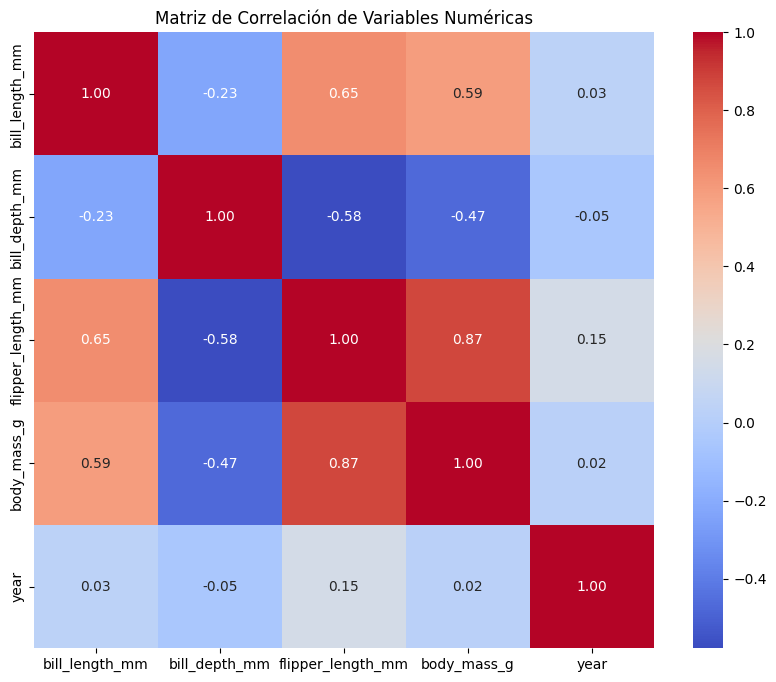

In [8]:
numerical_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df_cleaned[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

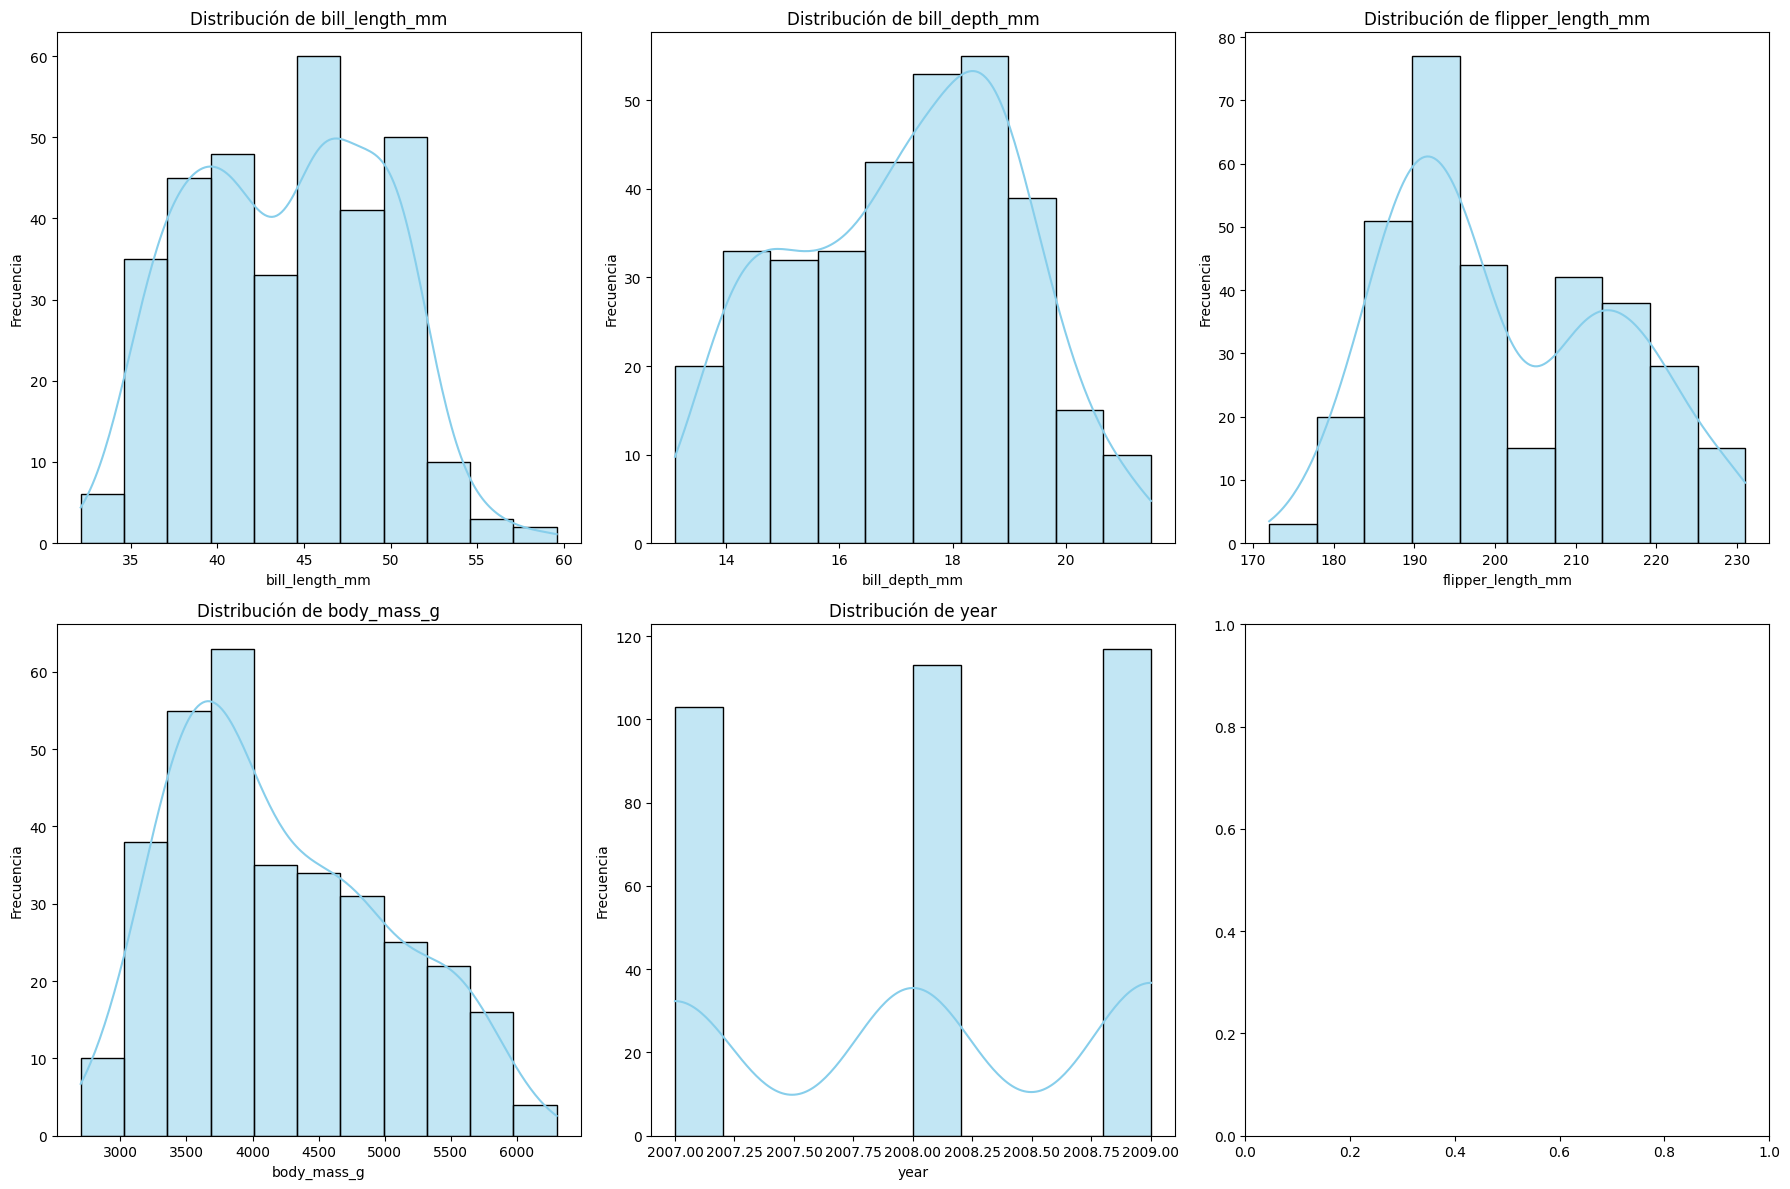

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

numerical_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.histplot(df_cleaned[col], kde=True, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Distribución de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

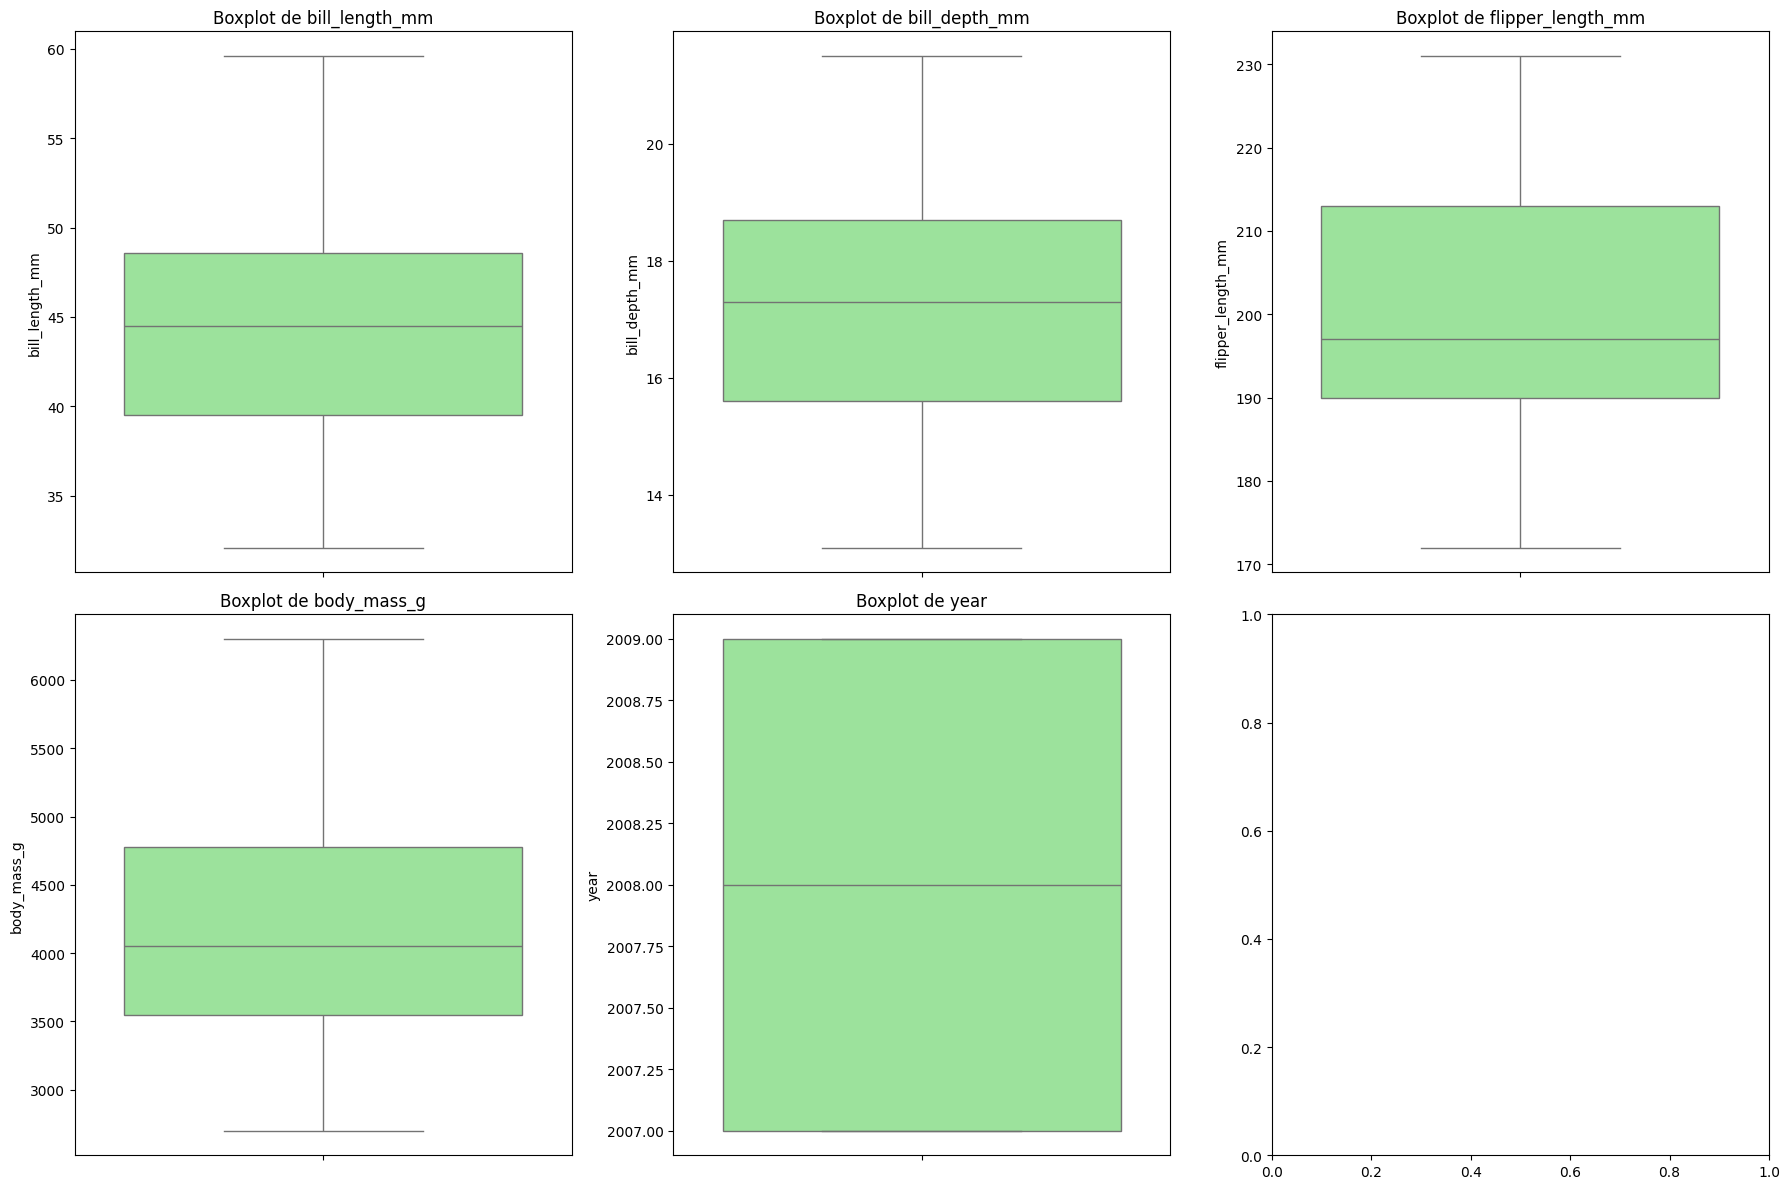

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

numerical_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.boxplot(y=df_cleaned[col], ax=axes[i], color='lightgreen')
        axes[i].set_title(f'Boxplot de {col}')
        axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [11]:
print("Resumen estadístico de las variables numéricas:")
print(df_cleaned[numerical_cols].describe())

Resumen estadístico de las variables numéricas:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      333.000000     333.000000         333.000000   333.000000   
mean        43.992793      17.164865         200.966967  4207.057057   
std          5.468668       1.969235          14.015765   805.215802   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.500000      15.600000         190.000000  3550.000000   
50%         44.500000      17.300000         197.000000  4050.000000   
75%         48.600000      18.700000         213.000000  4775.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   333.000000  
mean   2008.042042  
std       0.812944  
min    2007.000000  
25%    2007.000000  
50%    2008.000000  
75%    2009.000000  
max    2009.000000  


In [12]:
print("\nAnálisis de Outliers (Valores Atípicos) y Asimetría (Skewness):")

numerical_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()

for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]

    print(f"\n--- Columna: {col} ---")
    print(f"  Media: {df_cleaned[col].mean():.2f}")
    print(f"  Mediana: {df_cleaned[col].median():.2f}")
    print(f"  Asimetría (Skewness): {df_cleaned[col].skew():.2f}")
    print(f"  Número de outliers (IQR): {len(outliers)}")
    if not outliers.empty:
        print(outliers[[col]])



Análisis de Outliers (Valores Atípicos) y Asimetría (Skewness):

--- Columna: bill_length_mm ---
  Media: 43.99
  Mediana: 44.50
  Asimetría (Skewness): 0.05
  Número de outliers (IQR): 0

--- Columna: bill_depth_mm ---
  Media: 17.16
  Mediana: 17.30
  Asimetría (Skewness): -0.15
  Número de outliers (IQR): 0

--- Columna: flipper_length_mm ---
  Media: 200.97
  Mediana: 197.00
  Asimetría (Skewness): 0.36
  Número de outliers (IQR): 0

--- Columna: body_mass_g ---
  Media: 4207.06
  Mediana: 4050.00
  Asimetría (Skewness): 0.47
  Número de outliers (IQR): 0

--- Columna: year ---
  Media: 2008.04
  Mediana: 2008.00
  Asimetría (Skewness): -0.08
  Número de outliers (IQR): 0


In [13]:
df_final = pd.get_dummies(df_cleaned, columns=['species', 'island', 'sex'], drop_first=True)
print("Primeras 5 filas del DataFrame final después de la codificación:")
print(df_final.head())

print("\nInformación general del DataFrame final después de la codificación:")
df_final.info()


Primeras 5 filas del DataFrame final después de la codificación:
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  year  \
0            39.1           18.7              181.0       3750.0  2007   
1            39.5           17.4              186.0       3800.0  2007   
2            40.3           18.0              195.0       3250.0  2007   
4            36.7           19.3              193.0       3450.0  2007   
5            39.3           20.6              190.0       3650.0  2007   

   species_Chinstrap  species_Gentoo  island_Dream  island_Torgersen  sex_male  
0              False           False         False              True      True  
1              False           False         False              True     False  
2              False           False         False              True     False  
4              False           False         False              True     False  
5              False           False         False              True      True  

Inf

In [14]:
from sklearn.model_selection import train_test_split

# Definir las características (Variables independientes) (X) y la variable objetivo (y) para Regresión Lineal
# Usaremos 'body_mass_g' como variable objetivo continua para la regresión lineal
X_linear = df_final.drop(['body_mass_g'], axis=1)
y_linear = df_final['body_mass_g']

# Dividir los datos para Regresión Lineal
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(X_linear, y_linear, test_size=0.2, random_state=42)

print("Dimensiones de los datos para Regresión Lineal:")
print(f"X_train: {X_train_linear.shape}, y_train: {y_train_linear.shape}")
print(f"X_test: {X_test_linear.shape}, y_test: {y_test_linear.shape}")

Dimensiones de los datos para Regresión Lineal:
X_train: (266, 9), y_train: (266,)
X_test: (67, 9), y_test: (67,)


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Inicializar y entrenar el modelo de Regresión Lineal
linear_model = LinearRegression()
linear_model.fit(X_train_linear, y_train_linear)

# Realizar predicciones en el conjunto de prueba
y_pred_linear = linear_model.predict(X_test_linear)

# Evaluar el modelo
mae_linear = mean_absolute_error(y_test_linear, y_pred_linear)
mse_linear = mean_squared_error(y_test_linear, y_pred_linear)
rmse_linear = mse_linear**0.5 # Root Mean Squared Error
r2_linear = r2_score(y_test_linear, y_pred_linear)

print("\n--- Evaluación del Modelo de Regresión Lineal ---")
print(f"Error Absoluto Medio (MAE): {mae_linear:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse_linear:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_linear:.2f}")
print(f"Coeficiente de Determinación (R²): {r2_linear:.2f}")

print("\nCoeficientes del modelo:")
for feature, coef in zip(X_linear.columns, linear_model.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercepto: {linear_model.intercept_:.2f}")


--- Evaluación del Modelo de Regresión Lineal ---
Error Absoluto Medio (MAE): 204.02
Error Cuadrático Medio (MSE): 75702.46
Raíz del Error Cuadrático Medio (RMSE): 275.14
Coeficiente de Determinación (R²): 0.87

Coeficientes del modelo:
bill_length_mm: 22.42
bill_depth_mm: 64.46
flipper_length_mm: 16.87
year: -40.26
species_Chinstrap: -299.53
species_Gentoo: 930.28
island_Dream: 10.86
island_Torgersen: -60.83
sex_male: 376.92
Intercepto: 79100.00


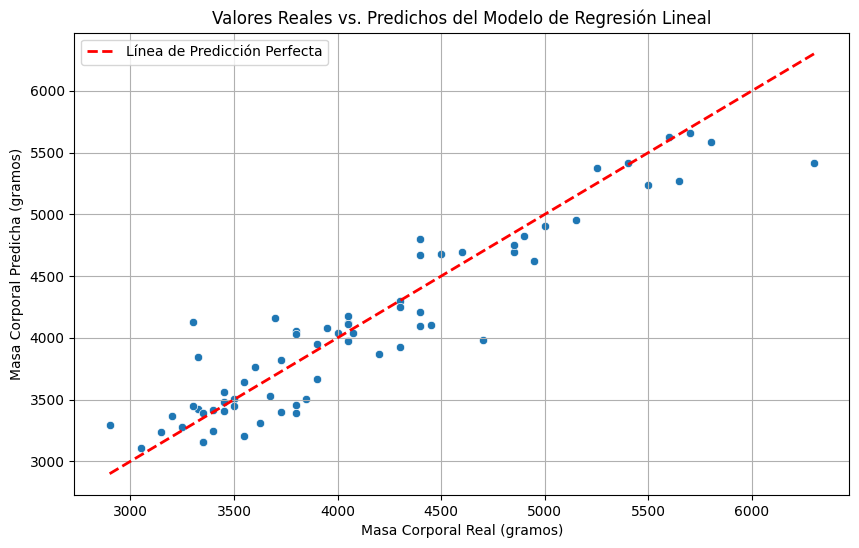

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de dispersión de los valores reales vs. predichos
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_linear, y=y_pred_linear)
plt.plot([y_test_linear.min(), y_test_linear.max()], [y_test_linear.min(), y_test_linear.max()], 'r--', lw=2, label='Línea de Predicción Perfecta')
plt.xlabel('Masa Corporal Real (gramos)')
plt.ylabel('Masa Corporal Predicha (gramos)')
plt.title('Valores Reales vs. Predichos del Modelo de Regresión Lineal')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

# Definir las características (X) y la variable objetivo (y) para Regresión Logística
# Usaremos 'sex_male' como variable objetivo binaria para la clasificación
X_logistic = df_final.drop(['sex_male'], axis=1)
y_logistic = df_final['sex_male']

# Dividir los datos para Regresión Logística
X_train_logistic, X_test_logistic, y_train_logistic, y_test_logistic = train_test_split(X_logistic, y_logistic, test_size=0.2, random_state=42)

print("Dimensiones de los datos para Regresión Logística:")
print(f"X_train: {X_train_logistic.shape}, y_train: {y_train_logistic.shape}")
print(f"X_test: {X_test_logistic.shape}, y_test: {y_test_logistic.shape}")

Dimensiones de los datos para Regresión Logística:
X_train: (266, 9), y_train: (266,)
X_test: (67, 9), y_test: (67,)



--- Evaluación del Modelo de Regresión Logística ---
Accuracy: 0.90
Precision: 0.85
Recall: 0.94
F1-Score: 0.89
ROC AUC Score: 0.95


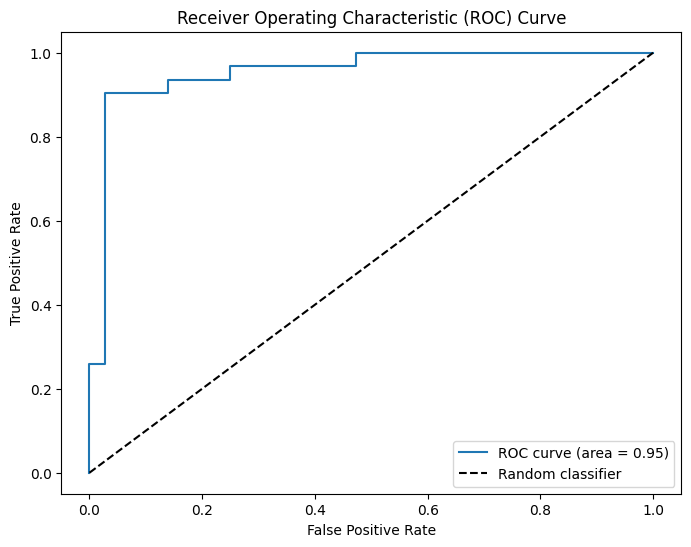

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Inicializar y entrenar el modelo de Regresión Logística
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_logistic, y_train_logistic)

# Realizar predicciones en el conjunto de prueba
y_pred_logistic = logistic_model.predict(X_test_logistic)
y_prob_logistic = logistic_model.predict_proba(X_test_logistic)[:, 1]

# Evaluar el modelo
accuracy = accuracy_score(y_test_logistic, y_pred_logistic)
precision = precision_score(y_test_logistic, y_pred_logistic)
recall = recall_score(y_test_logistic, y_pred_logistic)
f1 = f1_score(y_test_logistic, y_pred_logistic)
roc_auc = roc_auc_score(y_test_logistic, y_prob_logistic)

print("\n--- Evaluación del Modelo de Regresión Logística ---")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"ROC AUC Score: {roc_auc:.2f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test_logistic, y_prob_logistic)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()